# Section 3.2 and 3.3 Model Notebook
This notebook studies how government spending shocks affect a macroeconomy.

How to use this notebook:
1. Run cells from top to bottom.
2. First, build the baseline model and solve its steady state (Section 3.2).
3. Then compare model responses in low vs high productivity states (Section 3.3).

Big idea:
- Section 3.2 asks: "What happens after different government spending shocks?"
- Section 3.3 asks: "Do those effects change when productivity is low vs high?


## Parameters and Imports
This section loads libraries and sets the model's fixed numbers (parameters).

What these parameters mean in simple terms:
- `beta`: how patient households are (higher means more future-oriented).
- `sigma`: how strongly households dislike consumption fluctuations.
- `phi`: how responsive labor supply is to incentives.
- `alpha`: the share of output paid to capital.
- `delta`: how fast capital wears out each period.
#- `z_sim`: productivity level used in Section 3.2 baseline run. (MUST CHANGE)
#- Section 3.3 productivity states (`zL`, `zH`) are calibrated later from AR(1) parameters (`rho_z`, `sigma_eps`). (MUST CHANGE)
- `g_y_ratio`: normal government spending as a share of output.
- `shock_size`: size of the government spending shock.
- `T`: number of periods simulated after the shock.

These values act like the "settings" for the entire simulation.


In [ ]:
# Section 3.2
import numpy as np
from scipy.optimize import fsolve
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import os

# =============================================================================
# 1. PARAMETERS
# =============================================================================

beta      = 0.988
sigma     = 1.0
phi       = 1.0
alpha     = 0.33
delta     = 0.025
g_y_ratio = 0.20
target_L  = 1.0 / 3.0


z_states = np.array([0.99, 1.01])  # [z_low, z_high]
P = np.array([
    [0.875, 0.125],  # From Low to [Low, High]
    [0.125, 0.875]   # From High to [Low, High]
])

# Grid for VFI
k_grid_size = 200
k_grid = np.linspace(1.0, 25.0, k_grid_size)

T_PRE_FOR  = 4
T_DYN_FOR  = 36
T_PRE_UNF  = 5
T_DYN_UNF  = 35

GROUND_ZERO_FORESEEN   = 4
GROUND_ZERO_UNFORESEEN = 5

SHOCK_SIZES    = [0.01, 0.05, 0.10]
FORESEEN_LEADS = [1, 5, 9]
BENCHMARK_LEAD = 5
BENCHMARK_SIZE = 0.10

# Compatibility aliases used by Section 3.3 cells
T = T_PRE_FOR + T_DYN_FOR  # 40 -> time grid 0..40
shock_size = BENCHMARK_SIZE
foreseen_shock_date = GROUND_ZERO_UNFORESEEN
foreseen_announce_date = GROUND_ZERO_FORESEEN

## Core Model Equations
This section defines the economy's basic production relationships.

Equations here do three jobs:
- `production_function`: turns capital (`K`) and labor (`L`) into output (`Y`) using productivity (`z`).
- `marginal_product_labor`: gives the real wage (`w`) from one extra unit of labor.
- `marginal_product_capital`: gives the return to capital (`rk`) from one extra unit of capital.

Intuition:
- Better productivity (`z`) raises output and tends to raise factor returns.
- More capital and labor usually increase output, but with diminishing marginal gains.


In [9]:
# 2. Core model equations

def production_function(K, L, z):
    return z * (K ** alpha) * (L ** (1 - alpha))

def marginal_product_labor(K, L, z):
    return (1 - alpha) * z * (K ** alpha) * (L ** (-alpha))

def marginal_product_capital(K, L, z):
    return alpha * z * (K ** (alpha - 1)) * (L ** (1 - alpha))


In [59]:
# 3. Steady state

def solve_vfi_clean(chi, P, z_states, k_grid, params):
    beta, sigma, phi, alpha, delta, g_y_ratio = params
    n_k = len(k_grid)
    n_z = len(z_states)
    V = np.zeros((n_k, n_z))
    policy_indices = np.zeros((n_k, n_z), dtype=int)
    
    # Pre-calculate Labor (fixed at 1/3 for this step)
    L = 1/3
    dist = 1.0
    tol = 1e-7
    
    while dist > tol:
        V_old = V.copy()
        # EV is (n_k, n_z): Expected value of being at k' tomorrow for each current state
        EV = V_old @ P.T 
        
        for i_z in range(n_z):
            z = z_states[i_z]
            
            # Y: (n_k, 1) - Output for every possible K_today
            Y = z * (k_grid[:, None]**alpha) * (L**(1-alpha))
            
            # C: (n_k, n_k) - Consumption matrix for (K_today, K_tomorrow)
            # Y - delta*K - G + (K_today - K_tomorrow)
            C = (1 - g_y_ratio)*Y + (1 - delta)*k_grid[:, None] - k_grid[None, :]
            
            # Handle Sigma = 1 (Log Utility)
            if sigma == 1.0:
                # Use a small floor for C to avoid log(0)
                util_c = np.log(np.maximum(C, 1e-10))
            else:
                util_c = (np.maximum(C, 1e-10)**(1-sigma)) / (1-sigma)
            
            # Utility with a massive penalty for negative/zero consumption
            U = np.where(C > 1e-7, util_c - chi*(L**(1+phi))/(1+phi), -1e15)
            
            # Bellman Equation: Maximize over columns (K_tomorrow)
            # We add beta * EV of the chosen K_tomorrow
            V_mat = U + beta * EV[None, :, i_z] 
            
            V[:, i_z] = np.max(V_mat, axis=1)
            policy_indices[:, i_z] = np.argmax(V_mat, axis=1)
            
        dist = np.max(np.abs(V - V_old))
        
    policy_k_matrix = k_grid[policy_indices]
    return V, policy_k_matrix

In [63]:
# Create the mapping for the 'neutral' state (average productivity)
# or just pick the index where z is closest to 1.0
interp_policy = interp1d(k_grid, policy_k_matrix[:, 1], kind='linear', fill_value="extrapolate")

# Solve for SS Capital
k_ss = fsolve(lambda k: interp_policy(k) - k, 8.68)[0]

# Calculate the other variables at SS
y_ss = 1.0 * (k_ss**alpha) * (target_L**(1-alpha))
c_ss = (1 - g_y_ratio)*y_ss - delta*k_ss
print(f"Steady State Capital: {k_ss:.4f}")
print(f"Steady State Consumption: {c_ss:.4f}")

# Create interpolation functions for both states
k_policy_low = interp1d(k_grid, policy_k_matrix[:, 0], kind='linear', fill_value="extrapolate")
k_policy_high = interp1d(k_grid, policy_k_matrix[:, 1], kind='linear', fill_value="extrapolate")

# Find the fixed points K* for each state
k_star_low = fsolve(lambda k: k_policy_low(k) - k, 6.42)[0]
k_star_high = fsolve(lambda k: k_policy_high(k) - k, 6.42)[0]

# Use the average or the High state as your 'Baseline' for Section 3.2
ss_baseline_k = k_star_high 
print(f"Recession SS Capital: {k_star_low:.4f}")
print(f"Boom SS Capital: {k_star_high:.4f}")

Steady State Capital: 6.4196
Steady State Consumption: 0.5473
Recession SS Capital: 6.4200
Boom SS Capital: 6.4200


## Transition Dynamics
Steady state is one snapshot. This section builds the full time path after a shock.

Main idea:
- Solve for sequences over time: consumption `C_t`, labor `L_t`, and next-period capital `K_{t+1}`.

How it works:
- `pack_transition_variables` / `unpack_transition_variables` convert between arrays and the vector format needed by `fsolve`.
- `transition_system` stacks all period-by-period conditions:
  - labor condition each period,
  - resource/capital accumulation each period,
  - Euler equations linking today and tomorrow,
  - final (terminal) capital condition.
- `solve_transition_path` solves this system and reconstructs paths for `K`, `C`, `L`, `Y`, and `I`.

Intuition:
- After a shock, the economy does not jump instantly to a new long-run point; it adjusts gradually.


In [70]:
# 5. Simulate transition

def simulate_transition(k_start, z_val, g_path, params, chi_val, k_end=None):
    if k_end is None:
        k_end = k_start
        
    beta, sigma, phi, alpha, delta, g_y_ratio = params[:6]
    T = len(g_path)
    
    # vars: [K1...K_{T-1}, L0...L_{T-1}]
    initial_guess = np.concatenate([np.full(T-1, k_start), np.full(T, 1/3)])
    
    def equations(vars):
        K = np.zeros(T + 1); K[0] = k_start; K[T] = k_end
        K[1:T] = vars[:T-1]
        L = vars[T-1:]
        
        # 1. PRODUCTION & RESOURCE CONSTRAINT
        Y = z_val * (K[:-1]**alpha) * (L**(1-alpha))
        # C = Y + (1-delta)K - K_next - G
        C = Y + (1-delta)*K[:-1] - K[1:] - g_path
        C_safe = np.maximum(C, 1e-7)
        
        # 2. LABOR FOC: chi * L^phi = (1/C) * Wage
        w = (1-alpha) * Y / L
        labor_res = chi_val * (L**phi) - (C_safe**-sigma) * w
        
        # 3. EULER EQUATION
        rk_next = alpha * z_val * (K[1:T]**(alpha-1)) * (L[1:]**(1-alpha))
        euler_res = (C_safe[:-1]**-sigma) - beta * (C_safe[1:]**-sigma) * (rk_next + 1 - delta)
        
        return np.concatenate([euler_res, labor_res])

    sol = fsolve(equations, initial_guess)

    # Extract results
    K_f = np.zeros(T+1); K_f[0]=k_start; K_f[T]=k_end; K_f[1:T]=sol[:T-1]
    L_f = sol[T-1:]
    Y_f = z_val * (K_f[:-1]**alpha) * (L_f**(1-alpha))
    
    # CALCULATE INVESTMENT HERE
    # I = K_next - (1-delta)*K
    I_f = K_f[1:] - (1 - delta) * K_f[:-1]
    
    C_f = Y_f + (1-delta)*K_f[:-1] - K_f[1:] - g_path
    
    # Add 'I' to the dictionary
    return {"K": K_f[:-1], "Y": Y_f, "C": C_f, "L": L_f, "I": I_f, "G": g_path}
    
    
def prepend_ss(res_dict, ss_ref, n_pre=5):
    """
    Safely adds n_pre periods of steady state to the start of the simulation.
    Ensures all variables (Y, C, L, I, G, K) are extended consistently.
    """
    out = {}
    for var_name, path in res_dict.items():
        ss_val = ss_ref[var_name]
        buffer = np.full(n_pre, ss_val)
        out[var_name] = np.concatenate([buffer, path])
    return out

## Government Spending Shock Paths
This section creates the three shock experiments required in Section 3.2.

1. `make_foreseen_one_time_G_path`
- One temporary increase in `G`, announced in advance at a future date.

2. `make_unforeseen_one_time_G_path`
- One temporary increase in `G` that hits unexpectedly at time 0.

3. `make_permanent_G_path`
- An unexpected increase in `G` at time 0 that stays permanently.

Why we separate them:
- Timing and expectations matter in macro models, so each path can produce different responses.


In [41]:
# 6. Government spending paths for Section 3.2

def make_foreseen_path(G_ss, shock_size, lead):
    path = np.full(T_DYN_FOR + 1, G_ss)
    if lead <= T_DYN_FOR:
        path[lead] = G_ss * (1.0 + shock_size)
    return path


def make_unforeseen_onetime_path(G_ss, shock_size):
    path = np.full(T_DYN_UNF + 1, G_ss)
    path[0] = G_ss * (1.0 + shock_size)
    return path


def make_permanent_path(G_ss, shock_size):
    return np.full(T_DYN_UNF + 1, G_ss * (1.0 + shock_size))


# Backward-compatibility wrappers (full-horizon versions)
def make_foreseen_one_time_G_path(G_ss, shock_size, T, shock_date):
    G_path = np.full(T + 1, G_ss)
    G_path[shock_date] = G_ss * (1.0 + shock_size)
    return G_path


def make_unforeseen_one_time_G_path(G_ss, shock_size, T):
    G_path = np.full(T + 1, G_ss)
    G_path[0] = G_ss * (1.0 + shock_size)
    return G_path


def make_permanent_G_path(G_ss, shock_size, T):
    return np.full(T + 1, G_ss * (1.0 + shock_size))

def solve_steady_state_fixed_G(z, chi, G_fixed, initial_guess=(10.0, 0.33, 1.0)):
    """
    Solves for the steady state of the economy given a fixed level of G 
    (instead of a fixed G/Y ratio).
    """
    def equations(vars_vec):
        K, L, C = vars_vec
        # Production and Prices
        Y = z * (K**alpha) * (L**(1-alpha))
        w = (1-alpha) * z * (K**alpha) * (L**-alpha)
        rk = alpha * z * (K**(alpha-1)) * (L**(1-alpha))
        
        # 1. Euler: beta*(rk + 1 - delta) = 1
        res1 = beta * (rk + 1.0 - delta) - 1.0
        # 2. Labor FOC: chi * L^phi = w * C^-sigma
        res2 = chi * (L**phi) - w * (C**-sigma)
        # 3. Resource Constraint: Y = C + delta*K + G
        res3 = Y - C - delta*K - G_fixed
        
        return [res1, res2, res3]

    sol = fsolve(equations, initial_guess)
    K_ss, L_ss, C_ss = sol
    
    # Return a dictionary compatible with your SS reference
    Y_ss = z * (K_ss**alpha) * (L_ss**(1-alpha))
    return {
        "K": K_ss, "L": L_ss, "C": C_ss, 
        "Y": Y_ss, "G": G_fixed, "I": delta * K_ss
    }


## Plotting Utilities
These helper functions turn raw simulation output into readable figures.

- `percent_deviation`: converts each variable path into percentage deviation from steady state.
- `plot_irfs`: draws impulse response graphs for six variables:
  - Consumption (`C`), Labor (`L`), Investment (`I`), Output (`Y`), Capital (`K`), Government spending (`G`).

How to read the plots:
- 0% line means "back at steady state".
- Positive values mean above normal; negative values mean below normal.


In [71]:
# 7. Plotting

def pct_dev(path, ss_val):
    return 100.0 * (path - ss_val) / ss_val

# Backward-compatibility alias used in Section 3.3 plotting cells
def percent_deviation(path, steady_value):
    return pct_dev(path, steady_value)


def _with_visual_jump(tgrid, y, jump_t, eps=1e-3):
    """
    Keep smooth lines but render a discrete jump exactly at jump_t:
    insert a point at (jump_t-eps, y_{jump_t-1}) before (jump_t, y_{jump_t}).
    """
    t_arr = np.asarray(tgrid, dtype=float)
    y_arr = np.asarray(y, dtype=float)

    if jump_t <= 0 or jump_t >= len(t_arr):
        return t_arr, y_arr

    t_plot = np.insert(t_arr, jump_t, t_arr[jump_t] - eps)
    y_plot = np.insert(y_arr, jump_t, y_arr[jump_t - 1])
    return t_plot, y_plot


def plot_figure(foreseen_by_lead, res_unforeseen, res_permanent,
                ss, shock_size_pct, save_path=None):

    vars_plot  = [("C", "Consumption"), ("L", "Labour Supply"),
                  ("I", "Investment"),  ("Y", "Output")]
    row_labels = ["(1) Foreseen one-time",
                  "(2) Unforeseen one-time",
                  "(3) Unforeseen permanent"]
    colors     = ["#1f77b4", "#ff7f0e", "#2ca02c"]
    linestyles = ["-", "--", ":"]

    tgrid = np.arange(T_PRE_FOR + T_DYN_FOR + 1)   # 41 points t=0..40

    fig, axes = plt.subplots(
        3, 4, figsize=(15, 9),
        gridspec_kw={"hspace": 0.65, "wspace": 0.38}
    )

    is_benchmark = (shock_size_pct == int(BENCHMARK_SIZE * 100))

    for col, (var, var_label) in enumerate(vars_plot):

        # Row 1: foreseen one-time
        ax = axes[0, col]
        for lead, color, ls in zip(FORESEEN_LEADS, colors, linestyles):
            lw = 2.4 if (lead == BENCHMARK_LEAD and is_benchmark) else 1.6
            label = f"lead={lead}Q"
            full = prepend_ss(foreseen_by_lead[lead], ss, n_pre=T_PRE_FOR)
            y = pct_dev(full[var], ss[var])
            ax.plot(tgrid, y, label=label, color=color, linewidth=lw, linestyle=ls)

        ax.axvline(GROUND_ZERO_FORESEEN, color="gray", linewidth=0.8,
                   linestyle="--", alpha=0.7)
        ax.text(GROUND_ZERO_FORESEEN, 1, f"t={GROUND_ZERO_FORESEEN} (announced)",
                fontsize=6, color="gray", fontweight="bold",
                ha="center", va="bottom", transform=ax.get_xaxis_transform())
        ax.axvline(GROUND_ZERO_UNFORESEEN, color="dimgray", linewidth=0.8,
                   linestyle="--", alpha=0.7, ymin=0, ymax=1)
        ax.text(GROUND_ZERO_UNFORESEEN, -0.03, f"t={GROUND_ZERO_UNFORESEEN}",
                fontsize=6, color="dimgray", fontweight="bold",
                ha="center", va="top", transform=ax.get_xaxis_transform())
        ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
        ax.set_title(var_label, fontsize=10, fontweight="bold", pad=6)
        if col == 0:
            ax.set_ylabel(row_labels[0] + " | % dev. from SS", fontsize=7.5)
        else:
            ax.set_ylabel("% dev. from SS", fontsize=7.5)
        ax.set_xlabel("t", fontsize=9)
        ax.tick_params(labelsize=7)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.legend(fontsize=7, title="Foreseen lead",
                  title_fontsize=7, loc="best")

        # Row 2: unforeseen one-time
        ax = axes[1, col]
        full = prepend_ss(res_unforeseen, ss, n_pre=T_PRE_UNF)
        y = pct_dev(full[var], ss[var])
        tx, yy = _with_visual_jump(tgrid, y, GROUND_ZERO_UNFORESEEN)
        ax.plot(tx, yy, color="#1f77b4", linewidth=1.6)
        ax.axvline(GROUND_ZERO_UNFORESEEN, color="dimgray", linewidth=0.8,
                   linestyle="--", alpha=0.7, ymin=0, ymax=1)
        ax.text(GROUND_ZERO_UNFORESEEN, -0.03, f"t={GROUND_ZERO_UNFORESEEN}",
                fontsize=6, color="dimgray", fontweight="bold",
                ha="center", va="top", transform=ax.get_xaxis_transform())
        ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
        if col == 0:
            ax.set_ylabel(row_labels[1] + " | % dev. from SS", fontsize=7.5)
        else:
            ax.set_ylabel("% dev. from SS", fontsize=7.5)
        ax.set_xlabel("t", fontsize=9)
        ax.tick_params(labelsize=7)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        # Row 3: unforeseen permanent
        ax = axes[2, col]
        full = prepend_ss(res_permanent, ss, n_pre=T_PRE_UNF)
        y = pct_dev(full[var], ss[var])
        tx, yy = _with_visual_jump(tgrid, y, GROUND_ZERO_UNFORESEEN)
        ax.plot(tx, yy, color="#1f77b4", linewidth=1.6)
        ax.axvline(GROUND_ZERO_UNFORESEEN, color="dimgray", linewidth=0.8,
                   linestyle="--", alpha=0.7, ymin=0, ymax=1)
        ax.text(GROUND_ZERO_UNFORESEEN, -0.03, f"t={GROUND_ZERO_UNFORESEEN}",
                fontsize=6, color="dimgray", fontweight="bold",
                ha="center", va="top", transform=ax.get_xaxis_transform())
        ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
        if col == 0:
            ax.set_ylabel(row_labels[2] + " | % dev. from SS", fontsize=7.5)
        else:
            ax.set_ylabel("% dev. from SS", fontsize=7.5)
        ax.set_xlabel("t", fontsize=9)
        ax.tick_params(labelsize=7)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    benchmark_note = "  [Benchmark: 10% shock, lead=5Q]" if is_benchmark else ""
    fig.suptitle(
        f"Section 3.2: Government Spending Shock IRFs  -  "
        f"Shock size = {shock_size_pct}% of G_ss{benchmark_note}",
        fontsize=10, fontweight="bold", y=1.02
    )

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"  Saved: {save_path}")
    plt.show()
    plt.close(fig)


def plot_irfs(results, baseline_ss, title):
    """Legacy helper kept for compatibility."""
    tgrid = np.arange(len(results["C"]))
    fig, axes = plt.subplots(3, 2, figsize=(12, 10))
    axes = axes.flatten()

    series = [
        ("Consumption", results["C"], baseline_ss["C"]),
        ("Labor",       results["L"], baseline_ss["L"]),
        ("Investment",  results["I"], baseline_ss["I"]),
        ("Output",      results["Y"], baseline_ss["Y"]),
        ("Capital",     results["K"], baseline_ss["K"]),
        ("Government",  results["G"], baseline_ss["G"]),
    ]

    for ax, (name, path, ss_val) in zip(axes, series):
        ax.plot(tgrid, pct_dev(path, ss_val))
        ax.axhline(0.0, linewidth=0.8)
        ax.set_title(name)
        ax.set_xlabel("Time")
        ax.set_ylabel("% dev. from SS")

    fig.suptitle(title, fontsize=14)
    fig.tight_layout()
    plt.show()


## Section 3.2 Run
This cell executes the baseline experiment for one productivity level (`z_sim = 1.0`).

Workflow in this run:
1. Calibrate `chi` and compute baseline steady state.
2. Build the three government shock paths.
3. Set terminal conditions:
   - temporary shocks return to original steady state,
   - permanent shock converges to a new steady state with higher `G`.
4. Solve transition paths for each shock.
5. Plot IRFs.

This directly answers the Section 3.2 question.


--- Processing 1% Shock ---


C:\Users\65932\AppData\Local\Temp\ipykernel_26628\1988891993.py:34: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  sol = fsolve(equations, initial_guess)


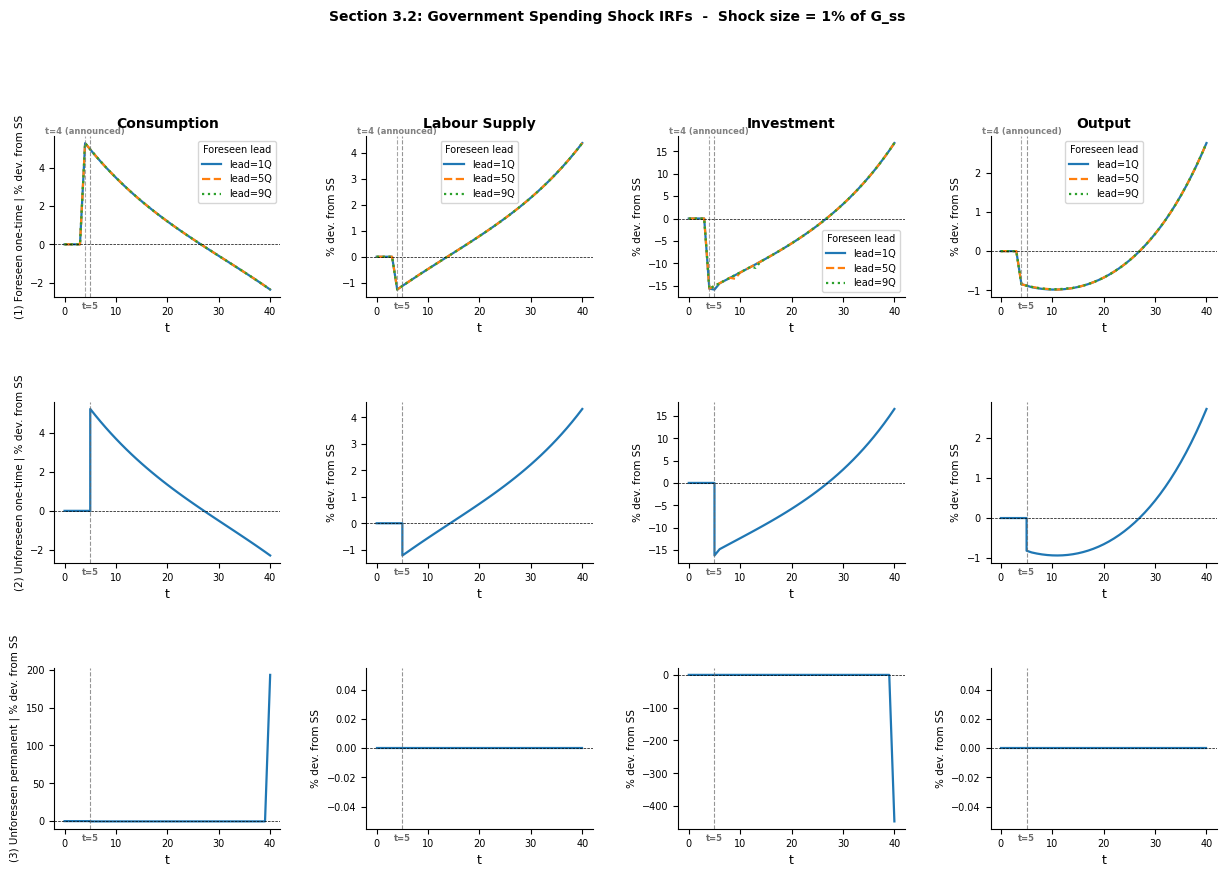

--- Processing 5% Shock ---


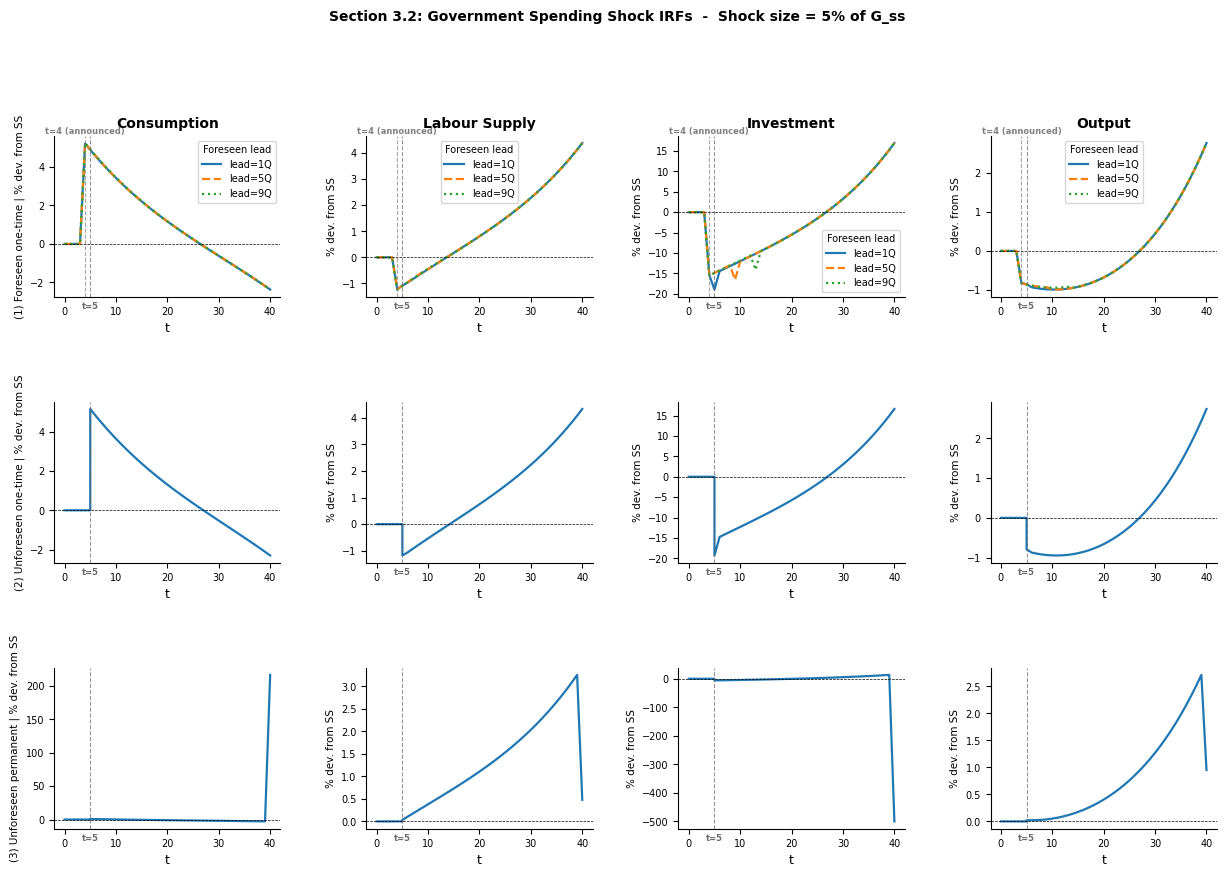

--- Processing 10% Shock ---


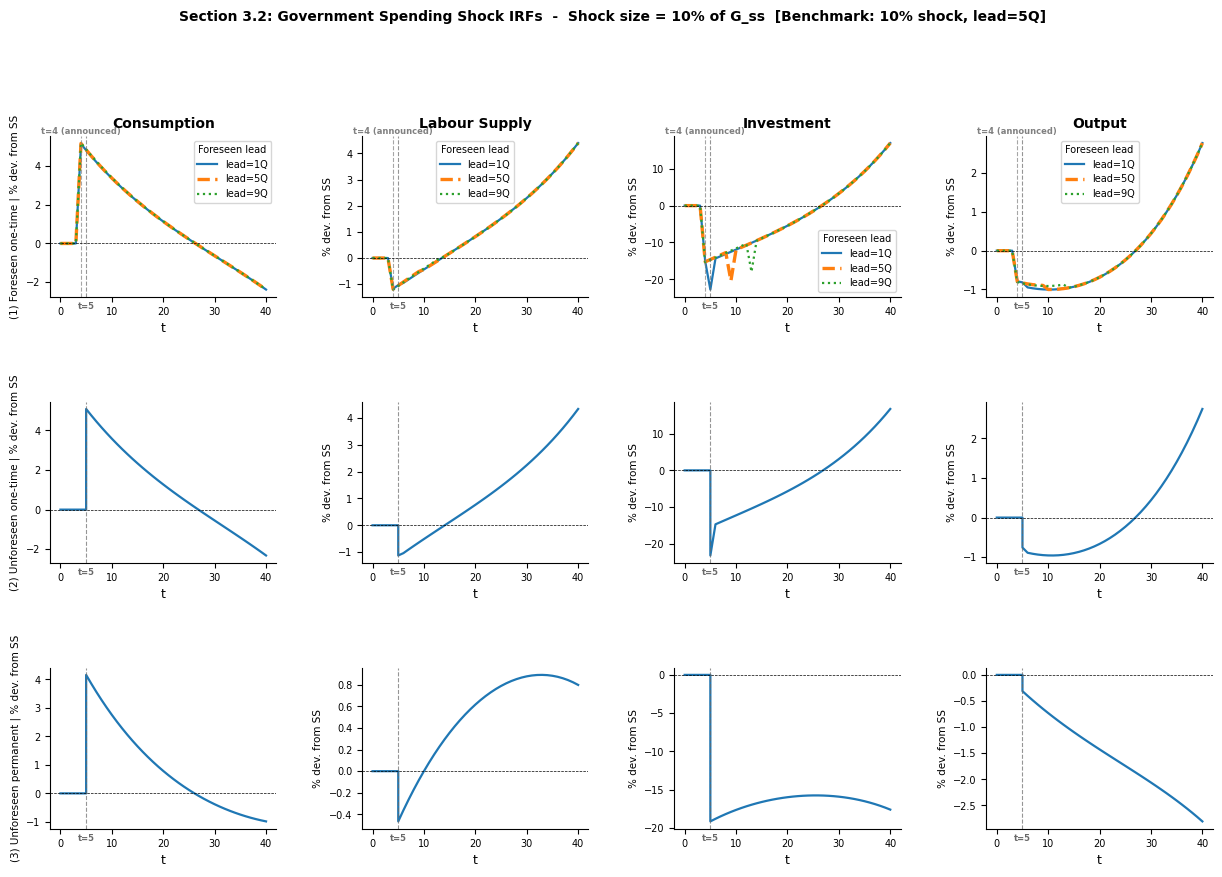

In [72]:
# 8. Main: Section 3.2
if __name__ == "__main__":
    # FIX THE STATE: We use high productivity (z=1.01) for the entire section
    z_ref = z_states[1] 
    ss_ref = ss_high
    
    # CRITICAL: Use the calibrated chi from your earlier cell
    # This ensures the simulation starts exactly at the steady-state baseline
    chi_val = chi 

    for current_shock_size in SHOCK_SIZES:
        size_pct = int(current_shock_size * 100)
        print(f"--- Processing {size_pct}% Shock ---")
        G_ss = ss_ref["G"]
        
        # 1. Unforeseen One-time
        G_unf = make_unforeseen_onetime_path(G_ss, current_shock_size)
        # Pass chi_val to the solver to ensure labor responds correctly
        res_unforeseen = simulate_transition(ss_ref["K"], z_ref, G_unf, params_vfi, chi_val=chi_val)
        
        # 2. Foreseen One-time
        foreseen_by_lead = {}
        for lead in FORESEEN_LEADS:
            G_for = make_foreseen_path(G_ss, current_shock_size, lead)
            foreseen_by_lead[lead] = simulate_transition(ss_ref["K"], z_ref, G_for, params_vfi, chi_val=chi_val)

        # 3. Unforeseen Permanent
        G_perm_val = G_ss * (1.0 + current_shock_size)
        
        # Solve for the NEW steady state where the economy will finish
        # This ensures the k_end target is mathematically consistent
        ss_perm = solve_steady_state_fixed_G(z_ref, chi_val, G_perm_val)
        
        G_perm_path = make_permanent_path(G_ss, current_shock_size)
        res_permanent = simulate_transition(
            ss_ref["K"], z_ref, G_perm_path, params_vfi, 
            chi_val=chi_val, k_end=ss_perm["K"]
        )

        # Run the plotting function
        # This uses the ss_ref["C"] as the absolute denominator for % dev
        plot_figure(
            foreseen_by_lead=foreseen_by_lead,
            res_unforeseen=res_unforeseen,
            res_permanent=res_permanent,
            ss=ss_ref,
            shock_size_pct=size_pct
        )

## Section 3.3 Helper (QuantEcon-Friendly)
This section builds a reusable 3.3 workflow without changing Section 3.2 code.

What is added here:
- optional QuantEcon import for state/Markov-chain context,
- the same three government-shock experiments, run conditionally at a chosen productivity state,
- a clean return object for plotting and comparison.

Important:
- If `quantecon` is not installed, the code still runs using the existing NumPy/SciPy setup.
- The core model equations and Section 3.2 logic remain unchanged.


In [8]:
# Section 3.3 helper: run the same 3.2 experiment conditional on one productivity state

# Optional QuantEcon support (safe fallback if unavailable)
try:
    import quantecon as qe
    HAS_QE = True
except Exception:
    HAS_QE = False

# Example transition matrix for productivity states (used for context in 3.3)
# Rows: current state, Columns: next state
# State order here is [zH, zL]
P_z = np.array([
    [0.95, 0.05],
    [0.05, 0.95]
])


def solve_state_steady_with_fixed_chi(z_value, chi_fixed, initial_guess=(10.0, 0.33, 1.0)):
    """
    Solve state steady state with fixed chi and fixed government share rule G = g_y_ratio * Y.
    """
    def steady_state_eq(vars_vec):
        K, L, C = vars_vec

        if K <= 0 or L <= 0 or C <= 0:
            return [1e6, 1e6, 1e6]

        Y = production_function(K, L, z_value)
        w = marginal_product_labor(K, L, z_value)
        rk = marginal_product_capital(K, L, z_value)

        G = g_y_ratio * Y

        eq1 = 1.0 - beta * (rk + 1.0 - delta)
        eq2 = chi_fixed * (L ** phi) - w * (C ** (-sigma))
        eq3 = Y - C - delta * K - G

        return [eq1, eq2, eq3]

    sol = fsolve(steady_state_eq, initial_guess)
    K_ss, L_ss, C_ss = sol

    Y_ss = production_function(K_ss, L_ss, z_value)
    I_ss = delta * K_ss
    G_ss = g_y_ratio * Y_ss
    w_ss = marginal_product_labor(K_ss, L_ss, z_value)
    rk_ss = marginal_product_capital(K_ss, L_ss, z_value)

    return {
        "K": K_ss,
        "L": L_ss,
        "C": C_ss,
        "Y": Y_ss,
        "I": I_ss,
        "G": G_ss,
        "w": w_ss,
        "rk": rk_ss,
    }


def run_state_experiment(z_value, state_label, chi_fixed=None, delta_G_abs=None):
    # Default to Section 3.2 calibrated chi (global variable from earlier cell)
    if chi_fixed is None:
        if "chi" in globals():
            chi_fixed = chi
        else:
            chi_fixed = calibrate_chi(z=z_sim, L_target=target_L, K_guess=10.0)["chi"]

    # State steady state under fixed chi
    baseline_ss = solve_state_steady_with_fixed_chi(
        z_value=z_value,
        chi_fixed=chi_fixed,
        initial_guess=(10.0, target_L, 1.0)
    )

    # Default absolute shock size: same absolute ΔG as in Section 3.2 reference
    if delta_G_abs is None:
        if "ss_baseline" in globals():
            delta_G_abs = shock_size * ss_baseline["G"]
        else:
            delta_G_abs = shock_size * baseline_ss["G"]

    G_ss_state = baseline_ss["G"]
    shock_frac = delta_G_abs / G_ss_state

    # (1) Foreseen one-time (benchmark lead), timeline follows Section 3.2
    lead = BENCHMARK_LEAD
    G_path_foreseen_dyn = make_foreseen_path(G_ss_state, shock_frac, lead)
    results_foreseen_dyn = solve_transition(
        baseline_ss["K"], z_value, chi_fixed,
        G_path_foreseen_dyn, baseline_ss, baseline_ss
    )
    results_foreseen = prepend_ss(results_foreseen_dyn, baseline_ss, n_pre=T_PRE_FOR)

    # (2) Unforeseen one-time at t = GROUND_ZERO_UNFORESEEN
    G_path_unforeseen_dyn = make_unforeseen_onetime_path(G_ss_state, shock_frac)
    results_unforeseen_dyn = solve_transition(
        baseline_ss["K"], z_value, chi_fixed,
        G_path_unforeseen_dyn, baseline_ss, baseline_ss
    )
    results_unforeseen = prepend_ss(results_unforeseen_dyn, baseline_ss, n_pre=T_PRE_UNF)

    # (3) Unforeseen permanent at t = GROUND_ZERO_UNFORESEEN
    G_perm = G_ss_state + delta_G_abs
    permanent_ss = solve_steady_state_fixed_G(
        z=z_value,
        chi=chi_fixed,
        G_fixed=G_perm,
        initial_guess=(baseline_ss["K"], baseline_ss["L"], baseline_ss["C"])
    )
    G_path_permanent_dyn = make_permanent_path(G_ss_state, shock_frac)
    results_permanent_dyn = solve_transition(
        baseline_ss["K"], z_value, chi_fixed,
        G_path_permanent_dyn, baseline_ss, permanent_ss
    )
    results_permanent = prepend_ss(results_permanent_dyn, baseline_ss, n_pre=T_PRE_UNF)

    print()
    print(f"State: {state_label} (z = {z_value:.3f})")
    print(f"Timing -> Foreseen: announce t={GROUND_ZERO_FORESEEN}, benchmark hit t={GROUND_ZERO_FORESEEN + BENCHMARK_LEAD}; Unforeseen hit t={GROUND_ZERO_UNFORESEEN}")
    print(f"Fixed chi: {chi_fixed:.4f} | Common absolute ΔG: {delta_G_abs:.4f}")
    print(f"L: {baseline_ss['L']:.4f}, K: {baseline_ss['K']:.4f}, C: {baseline_ss['C']:.4f}, I: {baseline_ss['I']:.4f}, Y: {baseline_ss['Y']:.4f}, G: {baseline_ss['G']:.4f}")

    return {
        "z": z_value,
        "label": state_label,
        "chi_fixed": chi_fixed,
        "delta_G_abs": delta_G_abs,
        "baseline_ss": baseline_ss,
        "results": {
            "foreseen": results_foreseen,
            "unforeseen": results_unforeseen,
            "permanent": results_permanent,
        }
    }


## Section 3.3 Run (Low vs High Productivity)
This section compares state-dependent fiscal responses using the same 3.2 policy scaling choices.

Key design choices for 3.3 in this notebook:
- Keep `chi` fixed across all states/regimes (use the value calibrated in Section 3.2).
- Use one common absolute fiscal shock size `ΔG` for all states/regimes, where:
  - `ΔG = shock_size * G_3.2_reference`.

We compare three symmetric AR(1)-implied productivity regimes:
- Reference (normal conditions): `rho = 0.90`, `sigma_eps = 0.007`
- Mild stress regime: `rho = 0.95`, `sigma_eps = 0.02`
- Extreme no-persistence case (illustrative): `rho = 0.00`, `sigma_eps = 0.007`

For each symmetric AR(1) regime:
- `sigma_log_z = sigma_eps / sqrt(1 - rho^2)`
- `zL = exp(-sigma_log_z)`
- `zH = exp(+sigma_log_z)`

We also include one manual asymmetric robustness regime:
- `zL = 0.95`, `zH = 1.08`
- asymmetric transition matrix (high state less frequent).


In [9]:
# Section 3.3: compare low- and high-productivity states across regimes

# Regime specs
# - type="ar1": compute symmetric zL/zH from (rho, sigma_eps)
# - type="manual": use explicit zL/zH and transition matrix P
# Calibration logic:
# - Hold rho fixed from normal to stress (persistence unchanged)
# - Raise sigma_eps in stress to represent higher uncertainty
regimes = {
    "Reference (normal)": {"type": "ar1", "rho": 0.90, "sigma_eps": 0.007},
    "Stress (high uncertainty)": {"type": "ar1", "rho": 0.90, "sigma_eps": 0.030},
    "Extreme no-persistence": {"type": "ar1", "rho": 0.00, "sigma_eps": 0.007},
    "Asymmetric robustness": {
        "type": "manual",
        "zL": 0.92,
        "zH": 1.10,
        # Rows: current [zH, zL], Cols: next [zH, zL]
        "P": np.array([
            [0.93, 0.07],
            [0.04, 0.96],
        ]),
    },
}

# Hold fixed across all states/regimes (from Section 3.2)
chi_ref_32 = chi
delta_G_ref_32 = shock_size * ss_baseline["G"]
print(f"Fixed chi from Section 3.2: {chi_ref_32:.4f}")
print(f"Common absolute fiscal shock from Section 3.2: ΔG = {delta_G_ref_32:.4f}")

experiments = {}

for regime_name, spec in regimes.items():
    regime_type = spec["type"]

    if regime_type == "ar1":
        rho_z = spec["rho"]
        sigma_eps = spec["sigma_eps"]

        sigma_log_z = sigma_eps / np.sqrt(1.0 - rho_z**2)
        z_H = float(np.exp(+sigma_log_z))
        z_L = float(np.exp(-sigma_log_z))

        # Regime-consistent symmetric transition matrix for a 2-state chain
        p_stay = (1.0 + rho_z) / 2.0
        p_switch = (1.0 - rho_z) / 2.0
        P_regime = np.array([
            [p_stay, p_switch],
            [p_switch, p_stay],
        ])

        print()
        print(f"=== {regime_name} ===")
        print(f"type = ar1 | rho = {rho_z:.3f}, sigma_eps = {sigma_eps:.4f}")
        print(f"sigma_log_z = {sigma_log_z:.4f}")
        print(f"states -> zL = {z_L:.3f}, zH = {z_H:.3f}")
        print(f"P = [[{p_stay:.3f}, {p_switch:.3f}], [{p_switch:.3f}, {p_stay:.3f}]]")

    elif regime_type == "manual":
        rho_z = None
        sigma_eps = None
        sigma_log_z = None

        z_L = float(spec["zL"])
        z_H = float(spec["zH"])
        P_regime = np.array(spec["P"], dtype=float)

        print()
        print(f"=== {regime_name} ===")
        print("type = manual (asymmetric)")
        print(f"states -> zL = {z_L:.3f}, zH = {z_H:.3f}")
        print(f"P = [[{P_regime[0,0]:.3f}, {P_regime[0,1]:.3f}], [{P_regime[1,0]:.3f}, {P_regime[1,1]:.3f}]]")

    else:
        raise ValueError(f"Unknown regime type: {regime_type}")

    if HAS_QE:
        mc = qe.MarkovChain(P_regime, state_values=np.array(["zH", "zL"]))
        pi = mc.stationary_distributions[0]
        z_mean = pi[0] * z_H + pi[1] * z_L
        print(f"stationary probs -> zH: {pi[0]:.3f}, zL: {pi[1]:.3f}")
        print(f"stationary mean productivity E[z] = {z_mean:.3f}")

    exp_low_tmp = run_state_experiment(
        z_L,
        f"{regime_name} - Low productivity",
        chi_fixed=chi_ref_32,
        delta_G_abs=delta_G_ref_32,
    )
    exp_high_tmp = run_state_experiment(
        z_H,
        f"{regime_name} - High productivity",
        chi_fixed=chi_ref_32,
        delta_G_abs=delta_G_ref_32,
    )

    experiments[regime_name] = {
        "low": exp_low_tmp,
        "high": exp_high_tmp,
        "type": regime_type,
        "rho": rho_z,
        "sigma_eps": sigma_eps,
        "sigma_log_z": sigma_log_z,
        "zL": z_L,
        "zH": z_H,
        "P": P_regime,
    }

# Default regime used by plotting cell below
selected_set = "Reference (normal)"
exp_low = experiments[selected_set]["low"]
exp_high = experiments[selected_set]["high"]
print()
print(f"Selected regime for detailed IRF plots: {selected_set}")
print("Tip: use grouped comparisons below for cleaner interpretation.")


Using rho = 0.95, sigma_eps = 0.010
Stationary log std. dev. = 0.0320
Symmetric states -> zL = 0.968, zH = 1.033
QuantEcon Markov chain loaded.
State order: ['zH' 'zL']
Stationary probabilities -> zH: 0.500, zL: 0.500

State: Low productivity (z = 0.97)
L: 0.3333, K: 9.0084, C: 0.5413, I: 0.2252, Y: 0.9582

State: High productivity (z = 1.03)
L: 0.3333, K: 9.9121, C: 0.5957, I: 0.2478, Y: 1.0543


## Section 3.3 Grouped Comparison Plots
For readability, we compare regimes in focused groups:
- Same persistence (`rho`), different volatility (`sigma_eps`): Reference vs Stress
- Same volatility (`sigma_eps`), different persistence (`rho`): Reference vs Extreme no-persistence
- Symmetric vs asymmetric state design: Reference vs Asymmetric robustness


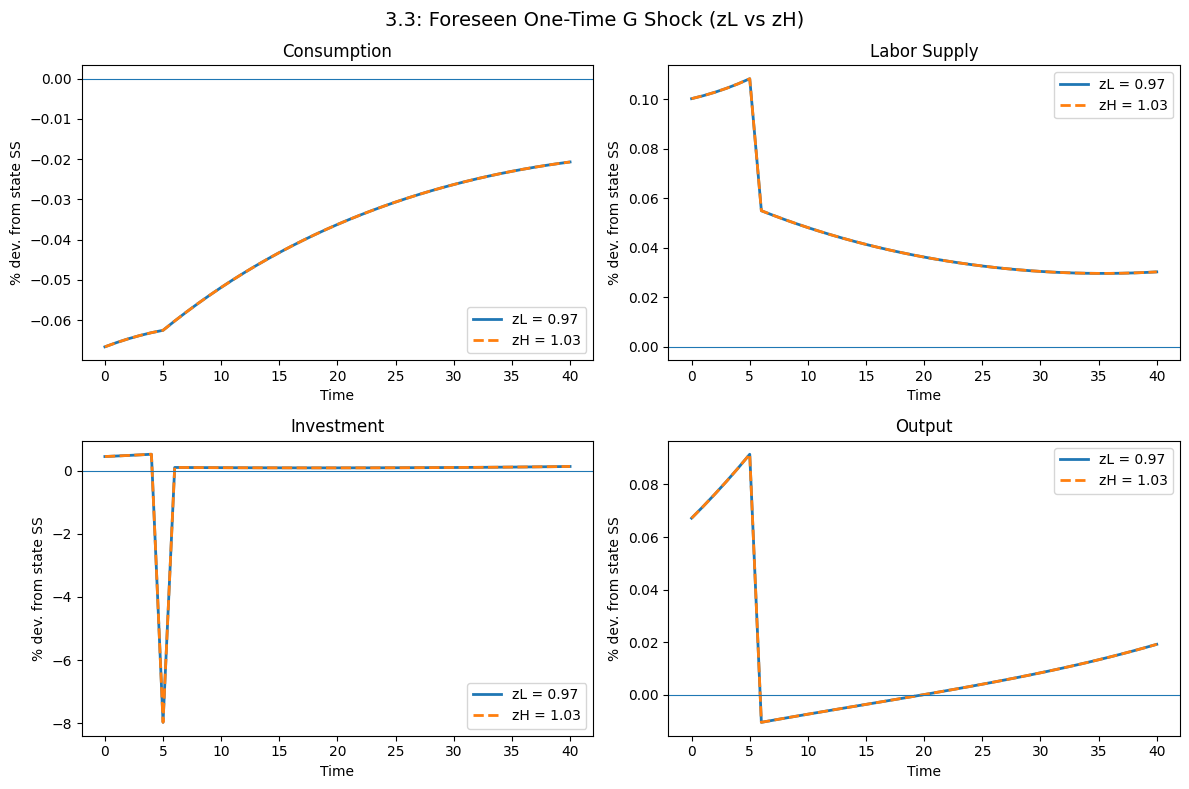

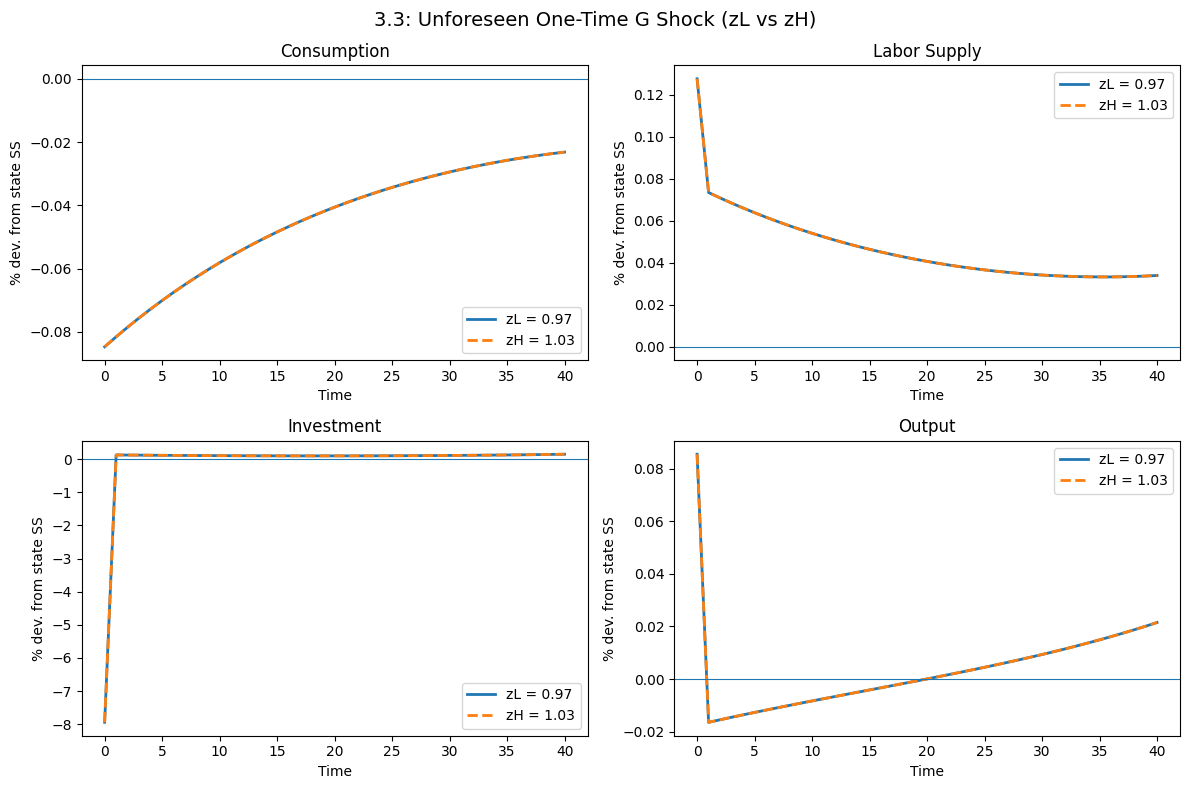

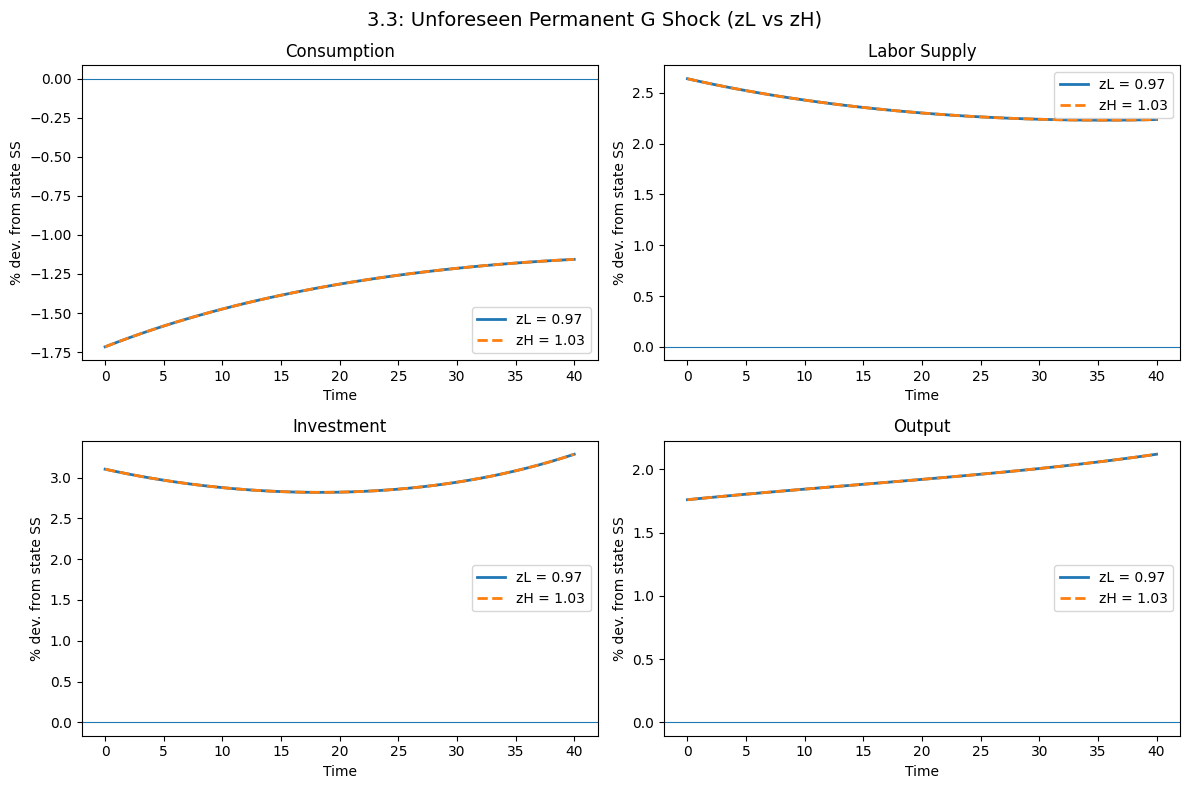

In [10]:
# Section 3.3 grouped overlays (with 3.2-consistent timing visuals)

# Fallback in case the 3.2 plotting cell was not run
if "_with_visual_jump" not in globals():
    def _with_visual_jump(tgrid, y, jump_t, eps=1e-3):
        t_arr = np.asarray(tgrid, dtype=float)
        y_arr = np.asarray(y, dtype=float)
        if jump_t <= 0 or jump_t >= len(t_arr):
            return t_arr, y_arr
        t_plot = np.insert(t_arr, jump_t, t_arr[jump_t] - eps)
        y_plot = np.insert(y_arr, jump_t, y_arr[jump_t - 1])
        return t_plot, y_plot


def _safe_name(text):
    return "".join(ch.lower() if ch.isalnum() else "_" for ch in text).strip("_")


def _subset_experiments(experiments, names):
    return {name: experiments[name] for name in names if name in experiments}


def plot_grouped_pairs_by_scenario(group_experiments, group_title, save_figures=False, file_prefix="fig_33_group"):
    """
    For a chosen subset of regimes, produce 3 figures (foreseen / unforeseen / permanent).
    Each figure is 2x2 (C, L, I, Y), overlaying zL (solid) and zH (dashed) for each regime.
    """
    vars_plot = [
        ("C", "Consumption"),
        ("L", "Labour Supply"),
        ("I", "Investment"),
        ("Y", "Output"),
    ]

    scenarios = [
        ("foreseen", "Foreseen One-Time G Shock", "foreseen"),
        ("unforeseen", "Unforeseen One-Time G Shock", "unforeseen"),
        ("permanent", "Unforeseen Permanent G Shock", "permanent"),
    ]

    regime_names = list(group_experiments.keys())
    cmap = plt.get_cmap("tab10")

    for shock_key, shock_label, shock_tag in scenarios:
        fig, axes = plt.subplots(2, 2, figsize=(12, 8))
        axes = axes.flatten()

        legend_handles = []
        legend_labels = []

        for ax_i, (ax, (var, var_name)) in enumerate(zip(axes, vars_plot)):
            for i, regime_name in enumerate(regime_names):
                color = cmap(i % 10)
                data = group_experiments[regime_name]

                low = data["low"]
                high = data["high"]

                low_dev = percent_deviation(low["results"][shock_key][var], low["baseline_ss"][var])
                high_dev = percent_deviation(high["results"][shock_key][var], high["baseline_ss"][var])
                tgrid = np.arange(len(low_dev))

                if shock_key in ("unforeseen", "permanent"):
                    tx_l, yy_l = _with_visual_jump(tgrid, low_dev, GROUND_ZERO_UNFORESEEN)
                    tx_h, yy_h = _with_visual_jump(tgrid, high_dev, GROUND_ZERO_UNFORESEEN)
                else:
                    tx_l, yy_l = tgrid, low_dev
                    tx_h, yy_h = tgrid, high_dev

                h_low, = ax.plot(
                    tx_l, yy_l,
                    color=color, linestyle="-", linewidth=1.7,
                    label=f"{regime_name} | zL={data['zL']:.3f}"
                )
                h_high, = ax.plot(
                    tx_h, yy_h,
                    color=color, linestyle="--", linewidth=1.7,
                    label=f"{regime_name} | zH={data['zH']:.3f}"
                )

                if ax_i == 0:
                    legend_handles.extend([h_low, h_high])
                    legend_labels.extend([
                        f"{regime_name} | zL={data['zL']:.3f}",
                        f"{regime_name} | zH={data['zH']:.3f}",
                    ])

            # timing markers, aligned with 3.2 story
            if shock_key == "foreseen":
                ax.axvline(GROUND_ZERO_FORESEEN, color="gray", linewidth=0.8, linestyle="--", alpha=0.7)
                ax.axvline(GROUND_ZERO_FORESEEN + BENCHMARK_LEAD, color="dimgray", linewidth=0.8, linestyle="--", alpha=0.7)
            else:
                ax.axvline(GROUND_ZERO_UNFORESEEN, color="dimgray", linewidth=0.8, linestyle="--", alpha=0.7)

            ax.axhline(0.0, color="black", linewidth=0.8)
            ax.set_title(var_name)
            ax.set_xlabel("Time")
            ax.set_ylabel("% dev. from state SS")
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

        fig.suptitle(f"3.3: {shock_label} | {group_title}", fontsize=14)
        fig.tight_layout(rect=[0, 0, 0.78, 0.95])
        fig.legend(
            legend_handles,
            legend_labels,
            loc="center left",
            bbox_to_anchor=(0.80, 0.5),
            fontsize=7,
            frameon=False,
        )

        if save_figures:
            fname = f"{file_prefix}_{_safe_name(group_title)}_{_safe_name(shock_tag)}.png"
            fig.savefig(fname, dpi=150, bbox_inches="tight")
            print(f"Saved: {fname}")

        plt.show()
        plt.close(fig)


def plot_all_pairs_by_scenario(experiments, save_figures=True, file_prefix="fig_33_overlay"):
    """Optional appendix: full overlay across all regimes."""
    plot_grouped_pairs_by_scenario(
        group_experiments=experiments,
        group_title="All regimes overlay",
        save_figures=save_figures,
        file_prefix=file_prefix,
    )


# Comparison A: same rho, different sigma
group_A = _subset_experiments(
    experiments,
    ["Reference (normal)", "Stress (high uncertainty)"]
)
plot_grouped_pairs_by_scenario(
    group_A,
    group_title="Same rho, different sigma",
    save_figures=False,
)

# Comparison B: same sigma, different rho
group_B = _subset_experiments(
    experiments,
    ["Reference (normal)", "Extreme no-persistence"]
)
plot_grouped_pairs_by_scenario(
    group_B,
    group_title="Same sigma, different rho",
    save_figures=False,
)

# Comparison C: symmetric vs asymmetric
group_C = _subset_experiments(
    experiments,
    ["Reference (normal)", "Asymmetric robustness"]
)
plot_grouped_pairs_by_scenario(
    group_C,
    group_title="Symmetric vs asymmetric",
    save_figures=False,
)

# Optional appendix: uncomment if needed
# plot_all_pairs_by_scenario(experiments, save_figures=True)


## Section 3.3 Output Comparison Table
This table summarizes steady-state outputs for each configured regime and productivity state.

Required outputs shown:
- Output (`Y`)
- Consumption (`C`)
- Investment (`I`)
- Labour (`L`)
- Capital (`K`)


In [ ]:
# Section 3.3 table: steady-state outputs across all regimes and states

# Build long-format table (one row per regime-state)
rows = []
for regime_name, set_data in experiments.items():
    for state_key, state_label in [("low", "zL"), ("high", "zH")]:
        ss = set_data[state_key]["baseline_ss"]
        rows.append({
            "Regime": regime_name,
            "State": state_label,
            "z": set_data["zL"] if state_key == "low" else set_data["zH"],
            "Y": ss["Y"],
            "C": ss["C"],
            "I": ss["I"],
            "L": ss["L"],
            "K": ss["K"],
        })

# Optional wide-format summary (one row per regime)
wide_rows = []
for regime_name, set_data in experiments.items():
    low_ss = set_data["low"]["baseline_ss"]
    high_ss = set_data["high"]["baseline_ss"]
    wide_rows.append({
        "Regime": regime_name,
        "zL": set_data["zL"],
        "zH": set_data["zH"],
        "Y(zL)": low_ss["Y"],
        "Y(zH)": high_ss["Y"],
        "C(zL)": low_ss["C"],
        "C(zH)": high_ss["C"],
        "I(zL)": low_ss["I"],
        "I(zH)": high_ss["I"],
        "L(zL)": low_ss["L"],
        "L(zH)": high_ss["L"],
        "K(zL)": low_ss["K"],
        "K(zH)": high_ss["K"],
    })

# Display nicely if pandas is available; fallback to plain printing otherwise
try:
    import pandas as pd
    from IPython.display import display

    df_long = pd.DataFrame(rows)
    df_long = df_long[["Regime", "State", "z", "Y", "C", "I", "L", "K"]]
    df_long = df_long.sort_values(["Regime", "State"]).reset_index(drop=True)

    df_wide = pd.DataFrame(wide_rows)
    df_wide = df_wide.sort_values("Regime").reset_index(drop=True)

    print("Long table (all regime-state rows):")
    display(df_long.round(4))

    print("\nWide table (one row per regime):")
    display(df_wide.round(4))

except Exception:
    print("Pandas/IPython display not available. Printing plain-text tables.\n")

    print("Long table:")
    header = f"{'Regime':30s} {'State':5s} {'z':>8s} {'Y':>8s} {'C':>8s} {'I':>8s} {'L':>8s} {'K':>8s}"
    print(header)
    print('-' * len(header))
    for r in rows:
        print(f"{r['Regime'][:30]:30s} {r['State']:5s} {r['z']:8.4f} {r['Y']:8.4f} {r['C']:8.4f} {r['I']:8.4f} {r['L']:8.4f} {r['K']:8.4f}")



## Section 3.3 Scenario Comparison Across All `zL`/`zH` Pairs
This section compares fiscal-policy responses for all regimes and both states (`zL`, `zH`) under each 3.2 shock scenario.

For each scenario, we report response metrics (in % deviations from state-specific steady state):
- `impact`: response at `t = 0`
- `peak_abs`: largest absolute response over time
- `avg_0_8`: average response from `t = 0` to `t = 8`

Variables included:
- Output (`Y`), Consumption (`C`), Investment (`I`), Labour (`L`), Capital (`K`)


In [ ]:
# Section 3.3 scenario-comparison tables across all regimes and states

scenario_name_map = {
    "foreseen": "Foreseen one-time",
    "unforeseen": "Unforeseen one-time",
    "permanent": "Unforeseen permanent",
}

# shock timing by scenario (aligned with Section 3.2 timeline)
shock_time_map = {
    "foreseen": GROUND_ZERO_FORESEEN + BENCHMARK_LEAD,
    "unforeseen": GROUND_ZERO_UNFORESEEN,
    "permanent": GROUND_ZERO_UNFORESEEN,
}

vars_report = ["Y", "C", "I", "L", "K"]

def irf_metrics(path, steady_state_value, shock_t, avg_horizon=8):
    dev = percent_deviation(path, steady_state_value)
    impact = float(dev[shock_t])
    peak_abs = float(dev[np.argmax(np.abs(dev))])
    end_t = min(len(dev) - 1, shock_t + avg_horizon)
    avg_shock_window = float(np.mean(dev[shock_t:end_t + 1]))
    return impact, peak_abs, avg_shock_window

rows = []
for regime_name, set_data in experiments.items():
    for state_key, state_label in [("low", "zL"), ("high", "zH")]:
        state_block = set_data[state_key]
        ss = state_block["baseline_ss"]
        z_val = set_data["zL"] if state_key == "low" else set_data["zH"]

        for scenario_key, scenario_label in scenario_name_map.items():
            res = state_block["results"][scenario_key]
            shock_t = shock_time_map[scenario_key]
            row = {
                "Regime": regime_name,
                "State": state_label,
                "z": z_val,
                "Scenario": scenario_label,
            }

            for var in vars_report:
                impact, peak_abs, avg_shock_0_8 = irf_metrics(
                    res[var], ss[var], shock_t=shock_t, avg_horizon=8
                )
                row[f"{var}_impact_%"] = impact
                row[f"{var}_peak_abs_%"] = peak_abs
                row[f"{var}_avg_shock_0_8_%"] = avg_shock_0_8

            rows.append(row)

try:
    import pandas as pd
    from IPython.display import display

    df = pd.DataFrame(rows)
    df = df.sort_values(["Scenario", "Regime", "State"]).reset_index(drop=True)

    for scenario_label in scenario_name_map.values():
        print(f"\n=== {scenario_label} ===")
        sub = df[df["Scenario"] == scenario_label].copy()
        display(sub.round(4))

except Exception:
    print("Pandas/IPython display not available. Printing compact plain-text summaries.\n")
    for scenario_label in scenario_name_map.values():
        print(f"\n=== {scenario_label} ===")
        print(f"{'Regime':28s} {'State':5s} {'z':>7s} {'Y_imp':>8s} {'Y_peak':>8s} {'C_imp':>8s} {'I_imp':>8s}")
        print('-' * 80)
        for r in rows:
            if r['Scenario'] != scenario_label:
                continue
            print(f"{r['Regime'][:28]:28s} {r['State']:5s} {r['z']:7.3f} {r['Y_impact_%']:8.3f} {r['Y_peak_abs_%']:8.3f} {r['C_impact_%']:8.3f} {r['I_impact_%']:8.3f}")
